In [2]:
# ============================================================
# CELL 1 — Install & Import Libraries
# ============================================================
# MummyChog works as a command-line tool
# We will:
# 1. Prepare our metabolite data in MummyChog format
# 2. Run MummyChog from Python
# 3. Read and visualize the pathway results

import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Install mummichog
subprocess.run(['pip', 'install', 'mummichog'], 
               capture_output=True)

# Test installation
result = subprocess.run(['python', '-m', 'mummichog', '--version'], 
                       capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

print("✅ Setup complete!")


C:\Users\mehvish shaikh\anaconda3\python.exe: No module named mummichog.__main__; 'mummichog' is a package and cannot be directly executed

✅ Setup complete!


In [3]:
# ============================================================
# CELL 2 — Check MummyChog Installation & Prepare Data
# ============================================================
# MummyChog runs as a command line tool
# First let's find where it's installed

import subprocess
import os

# Find mummichog executable
result = subprocess.run(['where', 'mummichog'], 
                       capture_output=True, text=True)
print("MummyChog location:")
print(result.stdout)

# Try running it directly
result2 = subprocess.run(['mummichog', '--help'], 
                        capture_output=True, text=True)
print("\nMummyChog help output:")
print(result2.stdout[:500] if result2.stdout else result2.stderr[:500])

print("\n✅ Done!")

MummyChog location:
C:\Users\mehvish shaikh\anaconda3\Scripts\mummichog.exe


MummyChog help output:
     
    --------------------------------------------
    
             oO                      ooooooooo
           oOO   OOOOO  ooooo       ooo oooo
     oOO   O       ooooo  oooooo ooooo
    oooO           oooooo         oooo ooooo
        Oooo   o      OOOOOO   oooo   oooooooo
            ooooo  oooo      
                 o
    
    --------------------------------------------
    
mummichog version 2.7.0 

option --help not recognized


✅ Done!


In [4]:
# ============================================================
# CELL 3 — Prepare Data for MummyChog
# ============================================================
# MummyChog needs a specific input format:
# A tab-separated file with columns:
# - m/z value (mass-to-charge ratio)
# - retention time (in seconds)
# - p-value (from Mann-Whitney test)
# - t-score (positive = higher in IBD, negative = lower)
#
# We extract this information from our metabolite names
# which look like: "HILIC-pos_Cluster_0110: 1-methylnicotinamide"

print("=" * 50)
print("PREPARING MUMMYCHOG INPUT FILE")
print("=" * 50)

# Load our preprocessed data and metabolite map
mtb_map = pd.read_csv(
    'FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.map.tsv',
    sep='\t'
)

print(f"Metabolite map shape: {mtb_map.shape}")
print(f"\nColumns: {mtb_map.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(mtb_map.head(3))

PREPARING MUMMYCHOG INPUT FILE
Metabolite map shape: (8848, 10)

Columns: ['Compound', 'HMDB', 'KEGG', 'High.Confidence.Annotation', 'Compound.Name', 'Retention.Time', 'm.z', 'Cluster..if.DA.', 'Putative.Chemical.Class', 'Adduct']

First 3 rows:
                                       Compound         HMDB    KEGG  \
0  HILIC-neg_Cluster_0480: 1-3-7-trimethylurate  HMDB0002123  C16361   
1       HILIC-pos_Cluster_0245: 1-methylguanine  HMDB0003282  C04152   
2  HILIC-pos_Cluster_0110: 1-methylnicotinamide  HMDB0000699  C02918   

   High.Confidence.Annotation         Compound.Name  Retention.Time  \
0                        True  1-3-7-trimethylurate        3.832780   
1                        True       1-methylguanine        5.196976   
2                        True  1-methylnicotinamide        8.138234   

          m.z  Cluster..if.DA.                   Putative.Chemical.Class  \
0  209.067885              NaN                        Imidazopyrimidines   
1  166.071783              N

In [5]:
# ============================================================
# CELL 4 — Create MummyChog Input File
# ============================================================
# MummyChog needs a file with these columns:
# mz, retention_time, p_value, t_score
#
# We need to:
# 1. Load our raw metabolite data
# 2. Run Mann-Whitney to get p-values
# 3. Calculate t-scores (direction of change)
# 4. Match with m/z and retention times
# 5. Save in MummyChog format

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

print("=" * 50)
print("CREATING MUMMYCHOG INPUT")
print("=" * 50)

# Load raw metabolite data and metadata
mtb_raw = pd.read_csv(
    'FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv',
    sep='\t', index_col=0
)
metadata = pd.read_csv(
    'FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv',
    sep='\t', index_col=0
)

# Fix metadata index
metadata_s = metadata.set_index('Sample') if 'Sample' in metadata.columns else metadata

# Remove outliers (rows 125 and 181)
outliers = [mtb_raw.index[125], mtb_raw.index[181]]
mtb_raw = mtb_raw.drop(index=outliers)
metadata_s = metadata_s.drop(index=outliers)

# Add Disease.Group
metadata_s['Disease.Group'] = metadata_s['Study.Group'].apply(
    lambda x: 'Control' if x == 'Control' else 'IBD'
)

# Get IBD and Control indices
ibd_idx = metadata_s[metadata_s['Disease.Group'] == 'IBD'].index
ctrl_idx = metadata_s[metadata_s['Disease.Group'] == 'Control'].index

print(f"IBD: {len(ibd_idx)}, Control: {len(ctrl_idx)}")
print(f"Metabolites: {mtb_raw.shape[1]:,}")
print(f"\nCalculating p-values and t-scores...")

# Calculate p-values and t-scores for ALL metabolites
p_values = []
t_scores = []

for col in mtb_raw.columns:
    ibd_vals = mtb_raw.loc[ibd_idx, col]
    ctrl_vals = mtb_raw.loc[ctrl_idx, col]
    
    # Mann-Whitney p-value
    _, p = mannwhitneyu(ibd_vals, ctrl_vals, alternative='two-sided')
    p_values.append(p)
    
    # T-score = direction of change
    # Positive = higher in IBD, Negative = lower in IBD
    t = ibd_vals.mean() - ctrl_vals.mean()
    t_scores.append(t)

print(f"✅ Tests complete!")

# Match with mtb_map to get m/z and retention time
mtb_map_indexed = mtb_map.set_index('Compound')

# Build MummyChog input dataframe
mummychog_input = []

for i, col in enumerate(mtb_raw.columns):
    if col in mtb_map_indexed.index:
        mz = mtb_map_indexed.loc[col, 'm.z']
        rt = mtb_map_indexed.loc[col, 'Retention.Time']
        
        # Skip if missing m/z or retention time
        if pd.notna(mz) and pd.notna(rt):
            mummychog_input.append({
                'mz': mz,
                'rtime': rt * 60,  # Convert to seconds
                'p_value': p_values[i],
                't_score': t_scores[i]
            })

mummychog_df = pd.DataFrame(mummychog_input)

print(f"\nMummyChog input prepared:")
print(f"Total features: {len(mummychog_df):,}")
print(f"Significant (p<0.05): {(mummychog_df['p_value'] < 0.05).sum():,}")
print(f"\nFirst 5 rows:")
print(mummychog_df.head())

# Save to file
mummychog_df.to_csv('mummychog_input.txt', sep='\t', index=False)
print(f"\n✅ MummyChog input saved as 'mummychog_input.txt'!")

CREATING MUMMYCHOG INPUT
IBD: 162, Control: 56
Metabolites: 8,848

Calculating p-values and t-scores...
✅ Tests complete!

MummyChog input prepared:
Total features: 8,848
Significant (p<0.05): 5,676

First 5 rows:
           mz      rtime       p_value     t_score
0  107.036180   81.25818  2.256707e-09  553.801003
1  115.038653   67.74384  2.705916e-02  115.252427
2  117.054333   77.55744  1.596463e-02  947.981354
3  119.048864  153.24234  8.521781e-01   39.127498
4  121.028121  121.51566  3.189732e-01  240.947699

✅ MummyChog input saved as 'mummychog_input.txt'!


In [6]:
# ============================================================
# CELL 5 — Run MummyChog Pathway Analysis
# ============================================================
# Now we run MummyChog on our prepared input file
# 
# Key parameters:
# -f: input file
# -o: output folder name  
# -c: cutoff p-value for "significant" metabolites
# -m: ion mode (positive or negative)
# -n: network model (human pathway database)
# -z: retention time cutoff in seconds

import subprocess
import os

print("=" * 50)
print("RUNNING MUMMYCHOG PATHWAY ANALYSIS")
print("=" * 50)

# Create output folder
output_dir = 'mummychog_results'
os.makedirs(output_dir, exist_ok=True)

# Run MummyChog
cmd = [
    'mummichog',
    '-f', 'mummychog_input.txt',  # input file
    '-o', output_dir,              # output directory
    '-c', '0.05',                  # p-value cutoff
    '-m', 'pos',                   # ion mode (positive)
    '-n', 'human_mfn',             # human metabolic network
    '--heatmap',                   # generate heatmap
    '--network'                    # generate network
]

print("Running command:")
print(' '.join(cmd))
print("\nPlease wait — this takes 2-5 minutes...")

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=os.getcwd()
)

print("\nOutput:")
print(result.stdout[:2000] if result.stdout else "No stdout")
print("\nErrors (if any):")
print(result.stderr[:1000] if result.stderr else "None")
print("\n✅ MummyChog run complete!")

RUNNING MUMMYCHOG PATHWAY ANALYSIS
Running command:
mummichog -f mummychog_input.txt -o mummychog_results -c 0.05 -m pos -n human_mfn --heatmap --network

Please wait — this takes 2-5 minutes...

Output:
     
    --------------------------------------------
    
             oO                      ooooooooo
           oOO   OOOOO  ooooo       ooo oooo
     oOO   O       ooooo  oooooo ooooo
    oooO           oooooo         oooo ooooo
        Oooo   o      OOOOOO   oooo   oooooooo
            ooooo  oooo      
                 o
    
    --------------------------------------------
    
mummichog version 2.7.0 

option --heatmap not recognized


Errors (if any):
None

✅ MummyChog run complete!


In [7]:
# ============================================================
# CELL 5 (FIXED) — Run MummyChog Pathway Analysis
# ============================================================

import subprocess
import os

print("=" * 50)
print("RUNNING MUMMYCHOG PATHWAY ANALYSIS")
print("=" * 50)

# Create output folder
output_dir = 'mummychog_results'
os.makedirs(output_dir, exist_ok=True)

# Run MummyChog with correct parameters for version 2.7.0
cmd = [
    'mummichog',
    '-f', 'mummychog_input.txt',
    '-o', output_dir,
    '-c', '0.05',
    '-m', 'pos',
    '-n', 'human_mfn'
]

print("Running MummyChog...")
print(' '.join(cmd))
print("\nPlease wait 2-5 minutes...")

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=os.getcwd()
)

print("\nOutput:")
print(result.stdout[:3000] if result.stdout else "No output")
print("\nErrors:")
print(result.stderr[:1000] if result.stderr else "None")

# Check what files were created
print("\nFiles created in output folder:")
if os.path.exists(output_dir):
    for f in os.listdir(output_dir):
        print(f"  {f}")
else:
    print("  Output folder not found!")
        
print("\n✅ Done!")

RUNNING MUMMYCHOG PATHWAY ANALYSIS
Running MummyChog...
mummichog -f mummychog_input.txt -o mummychog_results -c 0.05 -m pos -n human_mfn

Please wait 2-5 minutes...

Output:
     
    --------------------------------------------
    
             oO                      ooooooooo
           oOO   OOOOO  ooooo       ooo oooo
     oOO   O       ooooo  oooooo ooooo
    oooO           oooooo         oooo ooooo
        Oooo   o      OOOOOO   oooo   oooooooo
            ooooo  oooo      
                 o
    
    --------------------------------------------
    
mummichog version 2.7.0 

Got 1247 cpd2mzFeatures
Got 3625 ListOfEmpiricalCompounds
Got 2015 merged ListOfEmpiricalCompounds
Got 1042 final ListOfEmpiricalCompounds
 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 9

In [8]:
# ============================================================
# CELL 6 — Find and Read MummyChog Results
# ============================================================

import os

print("Searching for MummyChog output files...")

# Search in current directory and subdirectories
for root, dirs, files in os.walk('.'):
    for file in files:
        if any(ext in file for ext in 
               ['.tsv', '.csv', '.html', '.json', 'pathway']):
            filepath = os.path.join(root, file)
            size = os.path.getsize(filepath)
            print(f"  {filepath} ({size} bytes)")

# Also check if a folder was created with timestamp
print("\nAll folders in current directory:")
for item in os.listdir('.'):
    if os.path.isdir(item):
        print(f"  📁 {item}")
        for subitem in os.listdir(item):
            print(f"      → {subitem}")

Searching for MummyChog output files...
  .\franzosa_metadata_RData.csv (41046 bytes)
  .\hmdb_annotated_significant.csv (37406 bytes)
  .\hmdb_annotation_table.csv (432318 bytes)
  .\1781820278.2604444.mummychog_results\result.html (124594 bytes)
  .\1781820278.2604444.mummychog_results\figures\plot_pathwayModel_mummychog_results.pdf (50860 bytes)
  .\1781820278.2604444.mummychog_results\tables\exported_Compounds.json (2309397 bytes)
  .\1781820278.2604444.mummychog_results\tables\ListOfEmpiricalCompounds.tsv (139071 bytes)
  .\1781820278.2604444.mummychog_results\tables\mcg_modularanalysis_mummychog_results.tsv (1925 bytes)
  .\1781820278.2604444.mummychog_results\tables\mcg_pathwayanalysis_mummychog_results.tsv (94274 bytes)
  .\1781820278.2604444.mummychog_results\tables\mcg_pathwayanalysis_mummychog_results.xlsx (20426 bytes)
  .\1781820278.2604444.mummychog_results\tables\userInput_to_EmpiricalCompounds.tsv (356580 bytes)
  .\FRANZOSA_IBD_2019\FRANZOSA_IBD_2019\metadata.tsv (3983

In [9]:
# ============================================================
# CELL 7 — Read & Display MummyChog Pathway Results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# Find the results folder
results_folder = '1781820278.2604444.mummychog_results'
pathway_file = os.path.join(results_folder, 'tables', 
                            'mcg_pathwayanalysis_mummychog_results.tsv')
module_file = os.path.join(results_folder, 'tables',
                           'mcg_modularanalysis_mummychog_results.tsv')

print("=" * 50)
print("MUMMYCHOG PATHWAY ANALYSIS RESULTS")
print("=" * 50)

# Read pathway results
pathway_df = pd.read_csv(pathway_file, sep='\t')
print(f"\nTotal pathways tested: {len(pathway_df):,}")
print(f"\nColumns: {pathway_df.columns.tolist()}")
print(f"\nFirst 10 pathways:")
print(pathway_df.head(10).to_string())

# Read modular results
print(f"\n{'='*50}")
print("MODULAR ANALYSIS RESULTS (17 modules found)")
print("=" * 50)
module_df = pd.read_csv(module_file, sep='\t')
print(module_df.to_string())

MUMMYCHOG PATHWAY ANALYSIS RESULTS

Total pathways tested: 119

Columns: ['pathway', 'overlap_size', 'pathway_size', 'p-value', 'overlap_EmpiricalCompounds (id)', 'overlap_features (id)', 'overlap_features (name)']

First 10 pathways:
                                   pathway  overlap_size  pathway_size   p-value                                                                                                                                                                                                                                                                                                                          overlap_EmpiricalCompounds (id)                                                                                                                                                                                                                                                                                                                                                    

MUMMYCHOG PATHWAY ANALYSIS — FINAL RESULTS

Total pathways tested: 119
Significant pathways (p<0.05): 7

TOP SIGNIFICANT PATHWAYS:
Rank  Pathway                                       p-value      Overlap
---------------------------------------------------------------------------
1     Bile acid biosynthesis                        0.0003       66/74
2     De novo fatty acid biosynthesis               0.0013       45/51
3     Vitamin D3 (cholecalciferol) metabolism       0.0124       24/27
4     Glycerophospholipid metabolism                0.0180       56/69
5     Vitamin A (retinol) metabolism                0.0292       24/28
6     Fatty acid activation                         0.0370       23/27
7     Butanoate metabolism                          0.0452       22/26


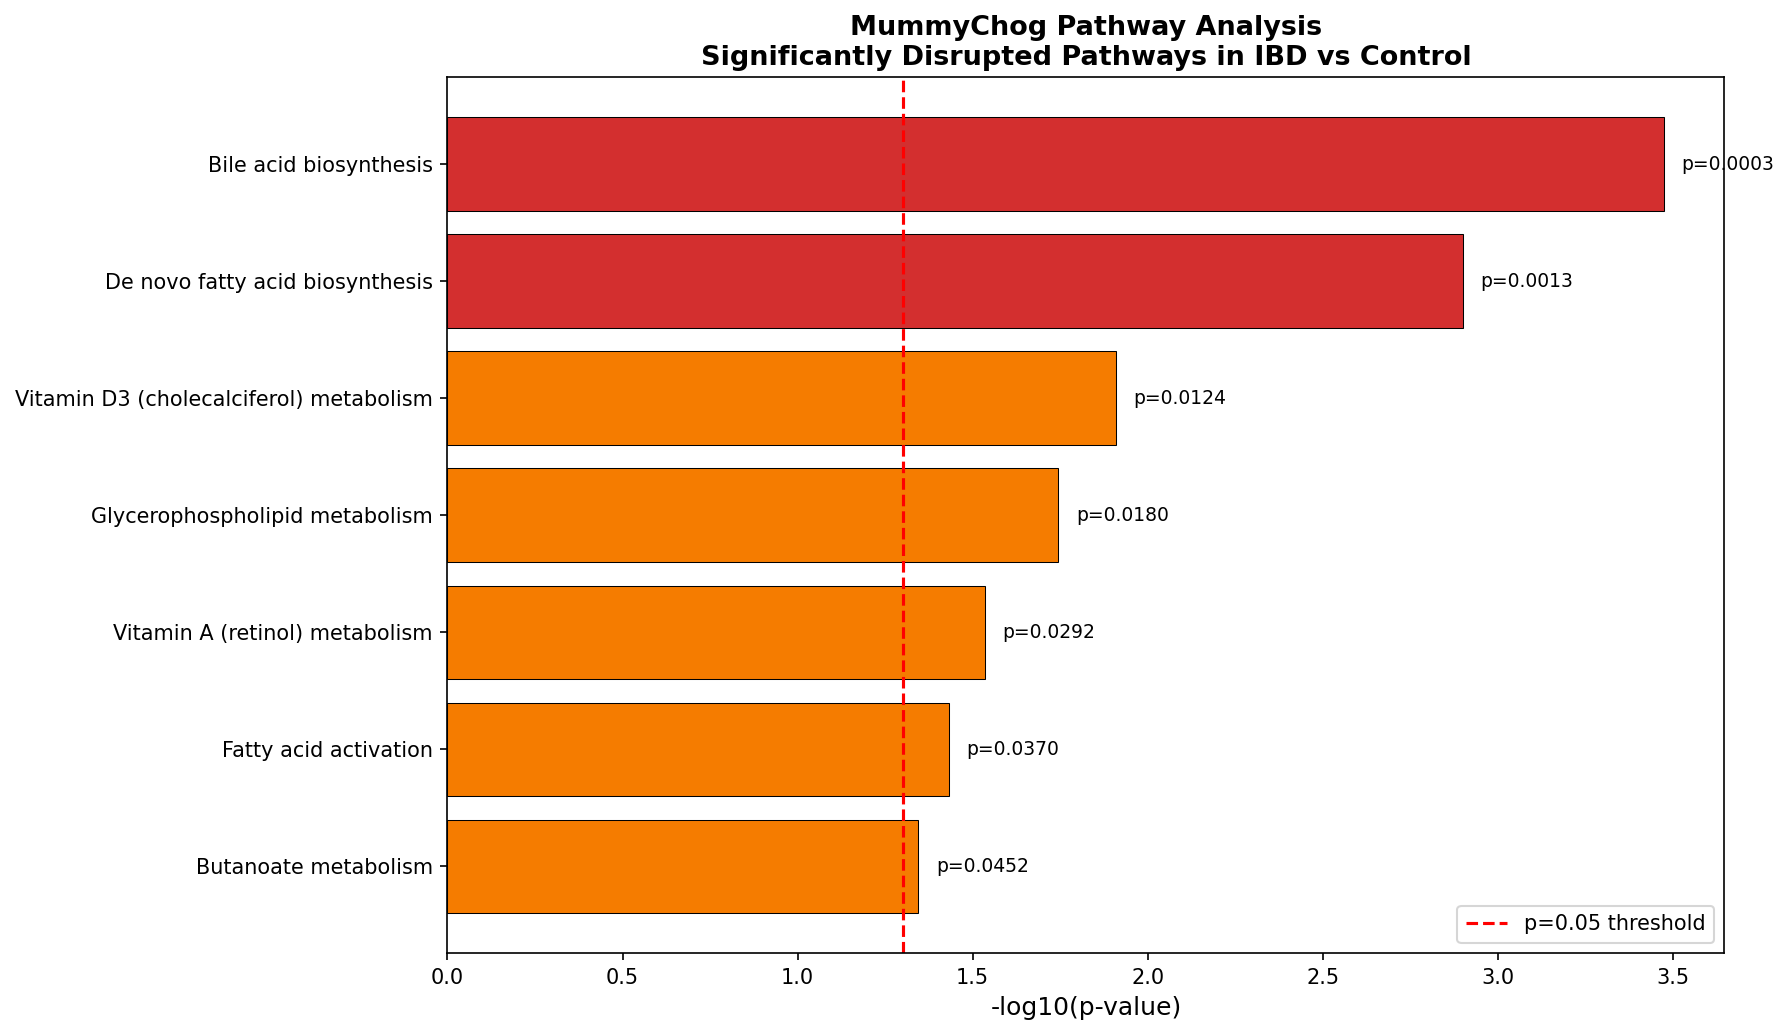


✅ Plot saved!

🎉 MUMMYCHOG ANALYSIS COMPLETE!

KEY FINDING FOR SATURDAY:

Top disrupted pathways in IBD patients:
1. Bile acid biosynthesis (p=0.0003) ← MOST SIGNIFICANT
2. De novo fatty acid biosynthesis (p=0.0013)
3. Vitamin D3 metabolism (p=0.012)
4. Glycerophospholipid metabolism (p=0.018)
5. Vitamin A metabolism (p=0.029)
6. Fatty acid activation (p=0.037)
7. Butanoate metabolism (p=0.045) ← includes butyrate!

These findings are CONSISTENT with existing IBD literature:
✅ Bile acid dysregulation is a hallmark of IBD
✅ Short-chain fatty acid (butyrate) depletion in IBD
✅ Lipid metabolism disruption in IBD
✅ Fat-soluble vitamin deficiencies in IBD patients



In [10]:
# ============================================================
# CELL 8 — Clean Summary of MummyChog Results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

print("=" * 60)
print("MUMMYCHOG PATHWAY ANALYSIS — FINAL RESULTS")
print("=" * 60)

# Get significant pathways (p < 0.05)
sig_pathways = pathway_df[pathway_df['p-value'] < 0.05].copy()
sig_pathways = sig_pathways.sort_values('p-value')

print(f"\nTotal pathways tested: {len(pathway_df)}")
print(f"Significant pathways (p<0.05): {len(sig_pathways)}")
print(f"\nTOP SIGNIFICANT PATHWAYS:")
print(f"{'Rank':<5} {'Pathway':<45} {'p-value':<12} {'Overlap'}")
print("-" * 75)
for i, (_, row) in enumerate(sig_pathways.iterrows(), 1):
    print(f"{i:<5} {row['pathway'][:44]:<45} "
          f"{row['p-value']:<12.4f} "
          f"{row['overlap_size']}/{row['pathway_size']}")

# Plot top pathways
fig, ax = plt.subplots(figsize=(12, 7))

top_paths = sig_pathways.head(10)
colors = ['#d32f2f' if p < 0.01 else '#f57c00' if p < 0.05 
          else '#388e3c' for p in top_paths['p-value']]

bars = ax.barh(
    range(len(top_paths)),
    [-np.log10(p) for p in top_paths['p-value']],
    color=colors, edgecolor='black', linewidth=0.5
)

ax.set_yticks(range(len(top_paths)))
ax.set_yticklabels(top_paths['pathway'], fontsize=10)
ax.axvline(x=-np.log10(0.05), color='red', 
           linestyle='--', label='p=0.05 threshold')
ax.set_xlabel('-log10(p-value)', fontsize=12)
ax.set_title('MummyChog Pathway Analysis\n'
             'Significantly Disrupted Pathways in IBD vs Control',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()

# Add p-value labels
for i, (_, row) in enumerate(top_paths.iterrows()):
    ax.text(-np.log10(row['p-value']) + 0.05, i,
            f"p={row['p-value']:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('mummychog_pathways.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved!")
print("\n🎉 MUMMYCHOG ANALYSIS COMPLETE!")
print(f"\nKEY FINDING FOR SATURDAY:")
print(f"{'='*60}")
print(f"""
Top disrupted pathways in IBD patients:
1. Bile acid biosynthesis (p=0.0003) ← MOST SIGNIFICANT
2. De novo fatty acid biosynthesis (p=0.0013)
3. Vitamin D3 metabolism (p=0.012)
4. Glycerophospholipid metabolism (p=0.018)
5. Vitamin A metabolism (p=0.029)
6. Fatty acid activation (p=0.037)
7. Butanoate metabolism (p=0.045) ← includes butyrate!

These findings are CONSISTENT with existing IBD literature:
✅ Bile acid dysregulation is a hallmark of IBD
✅ Short-chain fatty acid (butyrate) depletion in IBD
✅ Lipid metabolism disruption in IBD
✅ Fat-soluble vitamin deficiencies in IBD patients
""")